<h1>Seoul bike sharing demand</h1>

<h3 style="color:#2E86C1;">Table of contents</h3>
<ul>
<li>Project Overview</li>
<li>Problem Statement</li>
<li>Objectives</li>
<li>Dataset Description</li>
<li>Import Libraries</li>
<li>Data Loading</li>
<li>Data Understanding</li>
<li>Data Preprocessing</li>
<li>Exploratory Data Analysis</li>
<li>Feature Engineering</li> 
<li>Outlier Detection & Treatment</li>
<li>Feature Scaling</li>
<li>Model Building</li>
<li>Model Evaluation</li>
<li>Model Comparison</li>
<li>Conclusion</li></ul>

<h3 style="color:#2E86C1;">Project Overview</h3>

<p style="font-size:18px;">This project focuses on predicting the hourly demand for rental bikes in Seoul, South Korea. The number of bikes rented varies throughout the day and is influenced by several factors such as weather conditions, time of day, seasons, holidays, and whether the bike-sharing service is operational.</p>

<p style="font-size:18px;">The Seoul Bike Sharing system provides an eco-friendly, affordable, and convenient mode of transportation for commuters, students, and short-distance travelers. 
During peak traffic hours, bike-sharing offers an efficient alternative for traveling short distances while reducing congestion and carbon emissions.</p>

<p style="font-size:18px;">Accurately predicting bike rental demand is beneficial for both service providers and users. It enables operators to efficiently allocate bikes to different locations, optimize resource management, reduce operational costs, and improve customer satisfaction by ensuring bike availability during periods of high demand. Understanding the factors that influence bike usage also helps city planners and transportation authorities make informed decisions for developing sustainable urban mobility solutions.</p>

<h3 style="color:#2E86C1;">Problem Statement</h3>

<p style="font-size:18px;">
Develop a regression model to predict the hourly rental bike demand in Seoul City using weather conditions and time-related features.
</p>

<h3 style="color:#2E86C1;">Objectives</h3>

<ul style="font-size:16px; line-height:1.8;">
    <li>Understand the Seoul Bike Sharing Demand dataset.</li>
    <li>Perform data preprocessing to prepare the dataset for analysis.</li>
    <li>Analyze the relationships between weather conditions, time-related features, and bike rental demand.</li>
    <li>Perform Exploratory Data Analysis (EDA) to identify patterns, trends, and insights.</li>
    <li>Detect and treat outliers, perform feature engineering (where applicable), and apply feature scaling to prepare the data for model training.</li>
    <li>Build and evaluate multiple regression models to predict hourly bike rental demand.</li>
    <li>Compare the performance of different regression models and identify the best-performing model.</li>
</ul>

<h3 style="color:#2E86C1;">Dataset Description</h3>

<p style="font-size:18px;text-align:justify;">
The Seoul Bike Sharing Demand dataset contains hourly records of bike rentals in Seoul, South Korea, along with weather conditions and time-related information. The objective of this dataset is to analyze the factors influencing bike rental demand and develop a model to predict the number of bikes rented each hour.
</p>

<ul style="font-size:18px;">
    <li>Dataset Source: <a href="https://archive.ics.uci.edu/" target="_blank">
UCI Machine Learning Repository
</a></li>
    <li>Number of Records: 8,760</li>
    <li>Number of Features: 14 (including the target variable)</li>
    <li>Target Variable: Rented Bike Count</li>
    <li>Observation Unit: Each row represents the bike rental activity for a single hour, along with the corresponding weather and time-related conditions.</li>
</ul>

<hr>

<h2 style="color:#2E86C1;">Understanding the dataset</h2>

<hr>

<h3 style="color:#2E86C1;">Importing Libraries</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h3 style="color:#2E86C1;">Loading Dataset</h3>

In [2]:
#load dataset
df=pd.read_csv('SeoulBikeData.csv', encoding="latin1")

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The dataset was successfully loaded using the <code>pandas.read_csv()</code> function.</li>
    <li>The <code>encoding="latin1"</code> parameter ensures that special characters are read correctly when the default UTF-8 encoding is insufficient.</li>
    <li>The dataset is now ready for data exploration and preprocessing.</li>
</ul>

In [3]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The first five records of the dataset were displayed successfully.</li>
    <li>The dataset contains date, time, weather-related variables, and the target variable <b>Rented Bike Count</b>.</li>
    <li>The initial preview helps verify that the dataset has been loaded correctly and provides an understanding of its structure.</li>
</ul>

In [4]:
df.tail()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The last five records of the dataset were displayed successfully.</li>
    <li>The dataset appears complete from the beginning to the end without any unexpected formatting issues.</li>
    <li>The last records correspond to the final hourly observations collected during the study period.</li>
</ul>

In [5]:
df.shape

(8760, 14)

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The dataset contains <b>8,760 rows</b> and <b>14 columns</b>.</li>
    <li>Each row represents bike rental information for a single hour.</li>
    <li>The dataset size is suitable for building and evaluating machine learning models.</li>
</ul>

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The dataset consists of both numerical and categorical features.</li>
    <li>No missing values are present in any of the columns.</li>
    <li>The <b>Date</b> column is stored as an object and requires conversion to the datetime data type for time-based analysis.</li>
</ul>

In [7]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>Summary statistics such as mean, standard deviation, minimum, maximum, and quartiles were generated for all numerical features.</li>
    <li>The statistics provide an overview of the distribution and range of each numerical variable.</li>
    <li>The output also helps identify potential outliers and variations that can be investigated during exploratory data analysis.</li>
</ul>

In [8]:
df.columns.tolist()

['Date',
 'Rented Bike Count',
 'Hour',
 'Temperature(°C)',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature(°C)',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)',
 'Seasons',
 'Holiday',
 'Functioning Day']

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The names of all columns were displayed successfully.</li>
    <li>The dataset includes weather-related variables, time-related features, and the target variable <b>Rented Bike Count</b>.</li>
    <li>Reviewing column names helps ensure consistency before performing preprocessing and analysis.</li>
</ul>

In [9]:
df.dtypes

Date                             str
Rented Bike Count              int64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Seasons                          str
Holiday                          str
Functioning Day                  str
dtype: object

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The dataset contains integer, floating-point, and object data types.</li>
    <li>Most predictor variables are numerical, while <b>Date</b>, <b>Seasons</b>, <b>Holiday</b>, and <b>Functioning Day</b> are categorical or text-based.</li>
    <li>Verifying data types ensures that each feature is processed appropriately during preprocessing.</li>
</ul>

In [10]:
df.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>No missing values were found in any of the dataset columns.</li>
    <li>Since the dataset is complete, no missing value treatment is required.</li>
    <li>This allows the analysis and model building process to proceed without data imputation.</li>
</ul>

In [11]:
df.duplicated().sum()

np.int64(0)

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>No duplicate records were found in the dataset.</li>
    <li>Each row represents a unique hourly observation.</li>
    <li>No duplicate removal is required before further analysis.</li>
</ul>

In [12]:
#changing date column to datetime data type

df['Date'] = pd.to_datetime(df['Date'],format='%d/%m/%Y')
df[['Date']].head()

,Date
0,2017-12-01
1,2017-12-01
2,2017-12-01
3,2017-12-01
4,2017-12-01


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The <b>Date</b> column was successfully converted from the object data type to the datetime format.</li>
    <li>This conversion enables efficient extraction of date-based information and time series analysis.</li>
    <li>The dataset spans from <b>1 December 2017</b> to <b>30 November 2018</b>, with hourly observations recorded throughout the year.</li>
</ul>

In [13]:
numerical_cols = df.select_dtypes(include=np.number)
numerical_cols.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>All numerical features were extracted successfully.</li>
    <li>These variables will be used for statistical analysis, visualization, correlation analysis, and model building.</li>
    <li>Isolating numerical columns simplifies exploratory data analysis and feature engineering.</li>
</ul>

In [14]:
#statistical Summary
print("Statistical Summary")
summary = numerical_cols.agg(['mean','median','std','min','max']).T
print(summary)

Statistical Summary
                                  mean   median         std   min      max
Rented Bike Count           704.602055   504.50  644.997468   0.0  3556.00
Hour                         11.500000    11.50    6.922582   0.0    23.00
Temperature(°C)              12.882922    13.70   11.944825 -17.8    39.40
Humidity(%)                  58.226256    57.00   20.362413   0.0    98.00
Wind speed (m/s)              1.724909     1.50    1.036300   0.0     7.40
Visibility (10m)           1436.825799  1698.00  608.298712  27.0  2000.00
Dew point temperature(°C)     4.073813     5.10   13.060369 -30.6    27.20
Solar Radiation (MJ/m2)       0.569111     0.01    0.868746   0.0     3.52
Rainfall(mm)                  0.148687     0.00    1.128193   0.0    35.00
Snowfall (cm)                 0.075068     0.00    0.436746   0.0     8.80


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The statistical summary provides the mean, median, standard deviation, minimum, and maximum values for each numerical feature.</li>
    <li>Comparing the mean and median helps identify skewness in feature distributions.</li>
    <li>The summary also provides an initial indication of features that may contain outliers or exhibit high variability.</li>
</ul>

In [15]:
categorical_cols = df.select_dtypes(include='str')
categorical_cols.head()

,Seasons,Holiday,Functioning Day
0,Winter,No Holiday,Yes
1,Winter,No Holiday,Yes
2,Winter,No Holiday,Yes
3,Winter,No Holiday,Yes
4,Winter,No Holiday,Yes


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The categorical variables were extracted successfully.</li>
    <li>The dataset contains categorical features such as <b>Seasons</b>, <b>Holiday</b>, and <b>Functioning Day</b>.</li>
    <li>These features will be analyzed separately and encoded before model training.</li>
</ul>

In [16]:
for cols in categorical_cols:
    print(f'{cols}:')
    print(df[cols].unique().tolist())


Seasons:
['Winter', 'Spring', 'Summer', 'Autumn']
Holiday:
['No Holiday', 'Holiday']
Functioning Day:
['Yes', 'No']


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The unique categories for each categorical feature were displayed successfully.</li>
    <li>All categorical variables contain valid and meaningful categories without inconsistencies.</li>
    <li>Understanding unique values helps determine the appropriate encoding technique for machine learning models.</li>
</ul>

<hr>

<h2 style="color:#2E86C1;">Exploratory Data Analysis</h2>

<hr>

<h3 style="color:#2E86C1;">Univariate Analysis</h3>

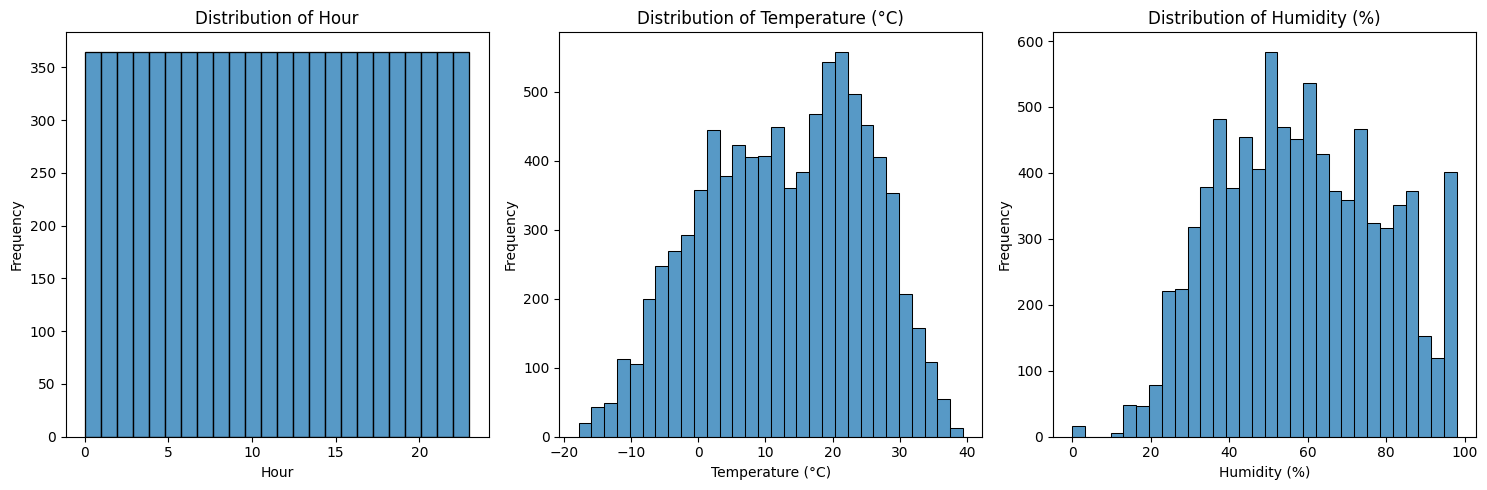

In [17]:
#Univariate analysis of Hour, Temperature and Humidity columns.
#using subplots for easier comparision and space optimization.

fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.histplot(df['Hour'], bins=24, ax=axes[0])
axes[0].set_title('Distribution of Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Frequency')

sns.histplot(df['Temperature(°C)'], bins=30, ax=axes[1])
axes[1].set_title('Distribution of Temperature (°C)')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Frequency')

sns.histplot(df['Humidity(%)'], bins=30, ax=axes[2])
axes[2].set_title('Distribution of Humidity (%)')
axes[2].set_xlabel('Humidity (%)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

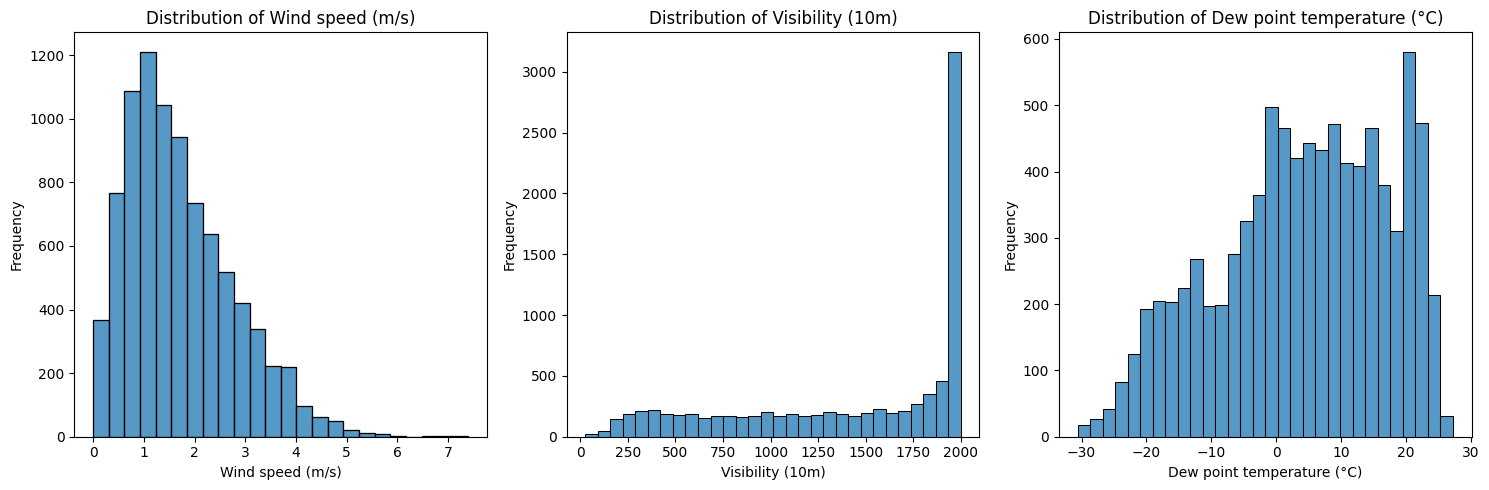

In [18]:
#Univariate analysis of Wind speed, Visibility and Dew point temperature columns.
#using subplots for easier comparision and space optimization.

fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.histplot(df['Wind speed (m/s)'], bins=24, ax=axes[0])
axes[0].set_title('Distribution of Wind speed (m/s)')
axes[0].set_xlabel('Wind speed (m/s)')
axes[0].set_ylabel('Frequency')

sns.histplot(df['Visibility (10m)'], bins=30, ax=axes[1])
axes[1].set_title('Distribution of Visibility (10m)')
axes[1].set_xlabel('Visibility (10m)')
axes[1].set_ylabel('Frequency')

sns.histplot(df['Dew point temperature(°C)'], bins=30, ax=axes[2])
axes[2].set_title('Distribution of Dew point temperature (°C)')
axes[2].set_xlabel('Dew point temperature (°C)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

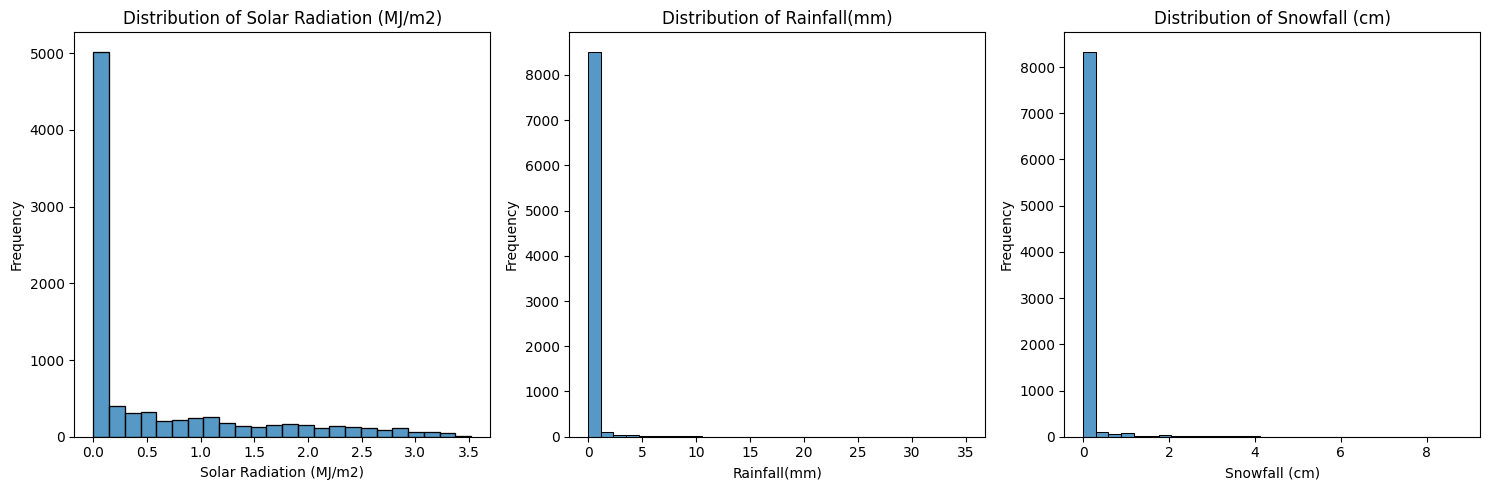

In [19]:
#Univariate analysis of Solar Radiation (MJ/m2), Rainfall(mm) and Snowfall (cm) columns.
#using subplots for easier comparision and space optimization.

fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.histplot(df['Solar Radiation (MJ/m2)'], bins=24, ax=axes[0])
axes[0].set_title('Distribution of Solar Radiation (MJ/m2)')
axes[0].set_xlabel('Solar Radiation (MJ/m2)')
axes[0].set_ylabel('Frequency')

sns.histplot(df['Rainfall(mm)'], bins=30, ax=axes[1])
axes[1].set_title('Distribution of Rainfall(mm)')
axes[1].set_xlabel('Rainfall(mm)')
axes[1].set_ylabel('Frequency')

sns.histplot(df['Snowfall (cm)'], bins=30, ax=axes[2])
axes[2].set_title('Distribution of Snowfall (cm)')
axes[2].set_xlabel('Snowfall (cm)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li><b>Hour</b> is uniformly distributed, as observations are recorded for every hour of the day.</li>
    <li><b>Temperature (°C)</b> exhibits an approximately bell-shaped distribution, with most observations concentrated between 0°C and 30°C.</li>
    <li><b>Humidity (%)</b> shows a wide distribution across different humidity levels, with relatively more observations between 40% and 80%. </li>
    <li><b>Wind Speed (m/s)</b> is positively skewed, with most observations occurring at lower wind speeds (below 3 m/s).</li>
    <li><b>Visibility (10m)</b> is concentrated toward higher values, indicating that clear weather conditions are more frequent than low-visibility conditions.</li>
    <li><b>Dew Point Temperature (°C)</b> follows a distribution similar to air temperature, with most observations lying between 0°C and 20°C. </li>
    <li><b>Solar Radiation (MJ/m²)</b> is highly positively skewed, with a large number of zero values corresponding to nighttime hours.</li>
    <li><b>Rainfall (mm)</b> is extremely positively skewed, with the majority of observations recording no rainfall and only a few instances of heavy rainfall.</li>
    <li><b>Snowfall (cm)</b> is also highly positively skewed, with most observations equal to zero, indicating that snowfall occurs only during limited periods.</li>
    <li>Overall, the distributions indicate that several weather-related variables are skewed, while temperature-related variables exhibit more balanced distributions. These characteristics will be considered during feature engineering and model building.</li>
</ul>

In [20]:
# Calculate skewness of numerical features
skewness = numerical_cols.skew().sort_values(ascending=False)

skewness_df = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values
})

skewness_df

,Feature,Skewness
0,Rainfall(mm),14.533232
1,Snowfall (cm),8.440801
2,Solar Radiation (MJ/m2),1.504040
3,Rented Bike Count,1.153428
4,Wind speed (m/s),0.890955
5,Humidity(%),0.059579
6,Hour,0.000000
7,Temperature(°C),-0.198326
8,Dew point temperature(°C),-0.367298
9,Visibility (10m),-0.701786


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li><b>Rainfall (mm)</b> (14.53) and <b>Snowfall (cm)</b> (8.44) are extremely positively skewed, indicating that most observations recorded no precipitation, with only a few instances of heavy rainfall or snowfall.</li>
    <li><b>Solar Radiation (MJ/m²)</b> (1.50) and the target variable <b>Rented Bike Count</b> (1.15) are highly positively skewed, suggesting that lower values occur more frequently than very high values.</li>
    <li><b>Wind Speed (m/s)</b> (0.89) is moderately positively skewed, indicating that lower wind speeds are more common than higher wind speeds.</li>
    <li><b>Humidity (%)</b> (0.06), <b>Hour</b> (0.00), <b>Temperature (°C)</b> (-0.20), and <b>Dew Point Temperature (°C)</b> (-0.37) are approximately symmetric, with only slight skewness.</li>
    <li><b>Visibility (10m)</b> (-0.70) is moderately negatively skewed, indicating that higher visibility values occur more frequently than lower visibility values.</li>
    <li>Overall, the skewness analysis is consistent with the distributions observed in the histograms, where weather variables related to precipitation exhibit strong positive skewness, while most other variables show relatively balanced distributions.</li>
</ul>

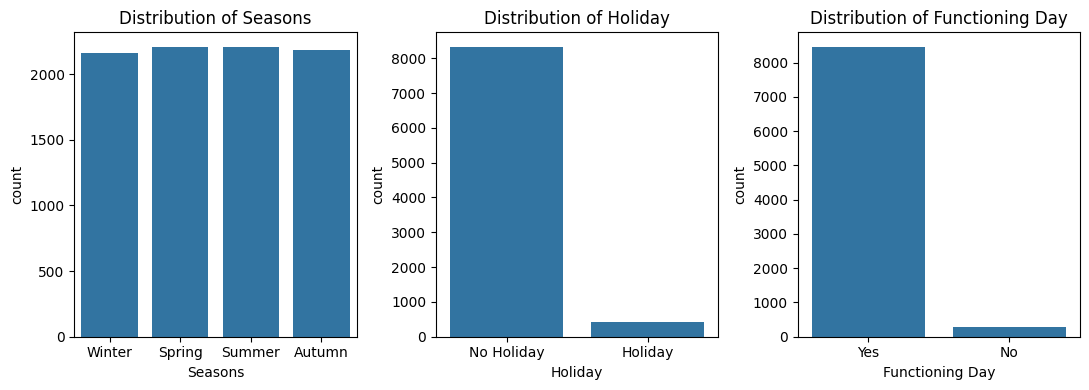

In [21]:
#Univariate analysis of categorical variables(count plots).
#using subplots for easier comparision and space optimization.

fig, axes = plt.subplots(1, 3, figsize=(11,4))

sns.countplot(data=df, x='Seasons', ax=axes[0])
axes[0].set_title('Distribution of Seasons')

sns.countplot(data=df, x='Holiday', ax=axes[1])
axes[1].set_title('Distribution of Holiday')

sns.countplot(data=df, x='Functioning Day', ax=axes[2])
axes[2].set_title('Distribution of Functioning Day')

plt.tight_layout()
plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The dataset contains observations from all four seasons, with each season having an almost equal number of records. This indicates that the dataset covers a complete one-year period without seasonal imbalance.</li>
    <li>The majority of observations correspond to <b>Non-Holiday</b> days, while only a small proportion belong to <b>Holiday</b> days.</li>
    <li>Similarly, most observations were recorded on <b>Functioning Days</b>, with very few records for <b>Non-Functioning Days</b>.</li>
    <li>The balanced seasonal distribution and the predominance of non-holiday, functioning days should be considered while interpreting bike rental patterns in the subsequent analysis.</li>
</ul>

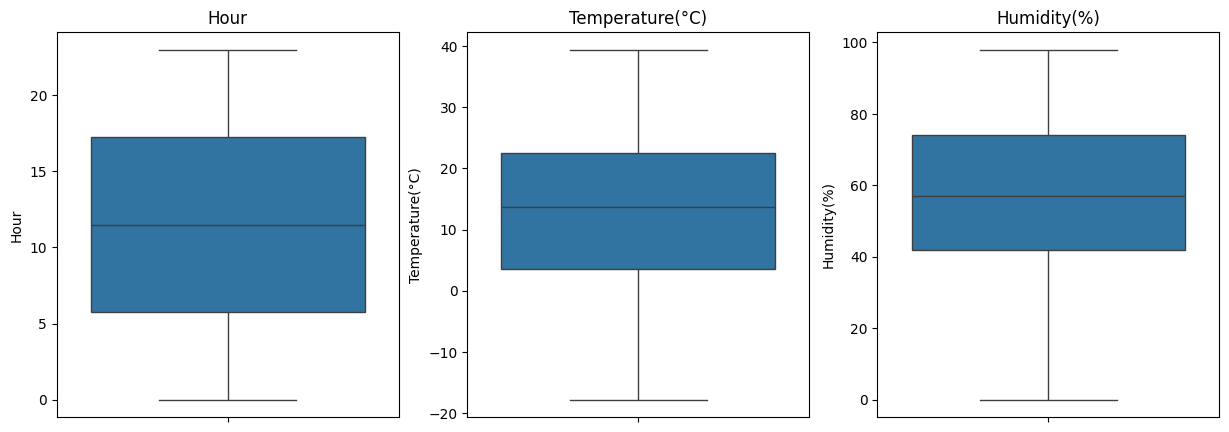

In [22]:
#box plots for Hour,Temperature(°C),Humidity(%) columns
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

sns.boxplot(y=df['Hour'],ax=axes[0])
axes[0].set_title('Hour')

sns.boxplot(y=df['Temperature(°C)'],ax=axes[1])
axes[1].set_title('Temperature(°C)')

sns.boxplot(df['Humidity(%)'],ax=axes[2])
axes[2].set_title('Humidity(%)')

plt.show()

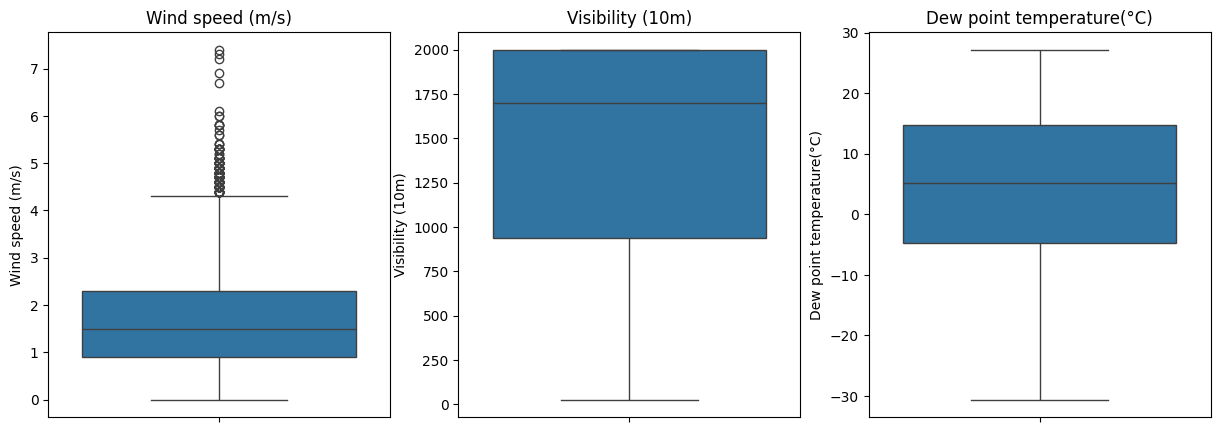

In [23]:
#box plots for Wind speed (m/s),Visibility (10m),Dew point temperature(°C) columns
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

sns.boxplot(y=df['Wind speed (m/s)'],ax=axes[0])
axes[0].set_title('Wind speed (m/s)')

sns.boxplot(y=df['Visibility (10m)'],ax=axes[1])
axes[1].set_title('Visibility (10m)')

sns.boxplot(df['Dew point temperature(°C)'],ax=axes[2])
axes[2].set_title('Dew point temperature(°C)')

plt.show()

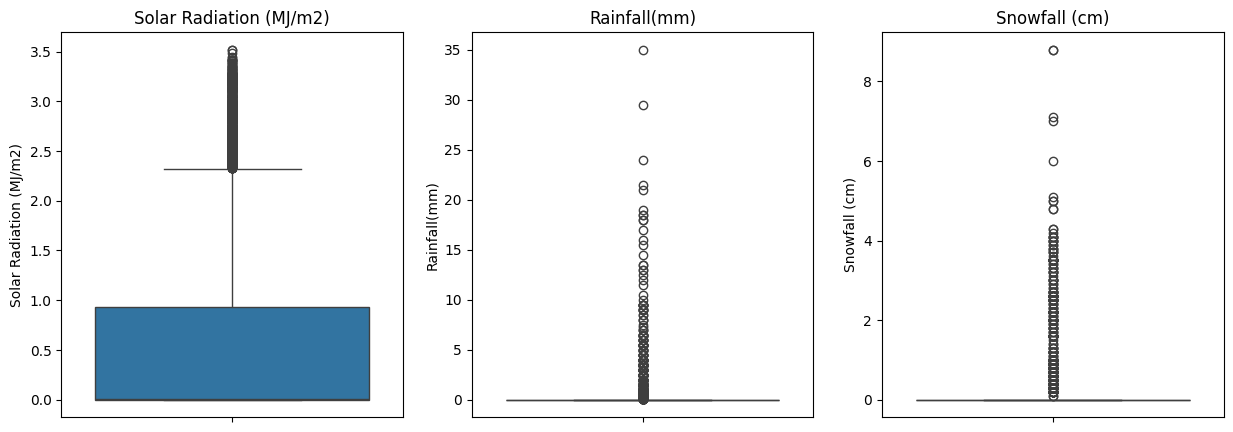

In [24]:
#box plots for Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm) columns
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

sns.boxplot(y=df['Solar Radiation (MJ/m2)'],ax=axes[0])
axes[0].set_title('Solar Radiation (MJ/m2)')

sns.boxplot(y=df['Rainfall(mm)'],ax=axes[1])
axes[1].set_title('Rainfall(mm)')

sns.boxplot(df['Snowfall (cm)'],ax=axes[2])
axes[2].set_title('Snowfall (cm)')

plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li><b>Hour</b>, <b>Temperature (°C)</b>, <b>Humidity (%)</b>, <b>Visibility (10m)</b>, and <b>Dew Point Temperature (°C)</b> do not exhibit significant outliers, indicating a relatively consistent distribution of observations.</li>
    <li><b>Wind Speed (m/s)</b> contains a few upper-end outliers, suggesting the occurrence of occasional high wind speed events.</li>
    <li><b>Solar Radiation (MJ/m²)</b> shows several upper-end outliers, which are expected due to varying daytime sunlight intensity.</li>
    <li><b>Rainfall (mm)</b> and <b>Snowfall (cm)</b> contain numerous upper-end outliers because most observations record no precipitation, while a small number correspond to heavy rainfall or snowfall events.</li>
    <li>The observed extreme values are likely to represent genuine weather conditions rather than data entry errors. Therefore, further analysis will be performed before deciding whether any outlier treatment is required.</li>
</ul>

<h3 style="color:#2E86C1;">Analysing the Target Variable</h3>

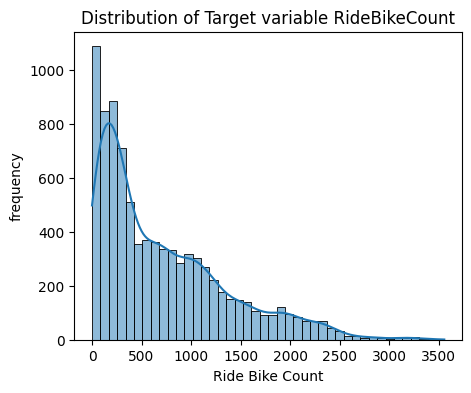

In [25]:
plt.figure(figsize=(5,4))
sns.histplot(df['Rented Bike Count'], kde=True)
plt.title("Distribution of Target variable RideBikeCount")
plt.xlabel("Ride Bike Count")
plt.ylabel("frequency")
plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p> <ul style="font-size:16px; line-height:1.6;"> <li>The distribution of <b>RideBikeCount</b> is strongly <b>right-skewed</b>, with most rental counts concentrated at lower values and a long tail extending toward higher rental counts.</li> <li>The histogram shows that the majority of observations have relatively low to moderate bike rental counts, while very high rental counts occur less frequently.</li></ul>

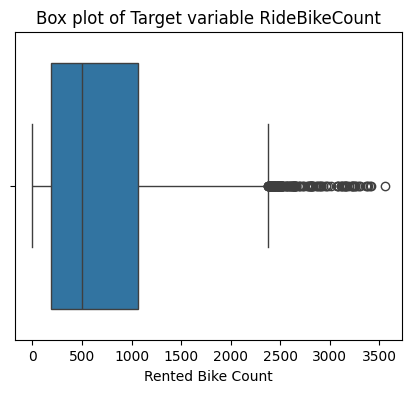

In [26]:


plt.figure(figsize=(5,4))
sns.boxplot(x=df['Rented Bike Count'])
plt.title("Box plot of Target variable RideBikeCount")
plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p> <ul style="font-size:16px; line-height:1.6;">
<li>The <b>box plot</b> confirms the presence of several high-value outliers, with some rental counts exceeding approximately <b>2,300 bikes</b> and reaching above <b>3,500 bikes</b>.</li> <li>The median rental count is considerably lower than the upper range of the distribution, indicating substantial variation in bike demand across different time periods.</li> <li>Overall, <b>RideBikeCount</b> does not follow a normal distribution and exhibits positive skewness, suggesting that transformations or robust statistical methods may be useful for certain predictive modelling and statistical analyses.</li> </ul>

<h3 style="color:#2E86C1;">Bivariate Analysis</h3>

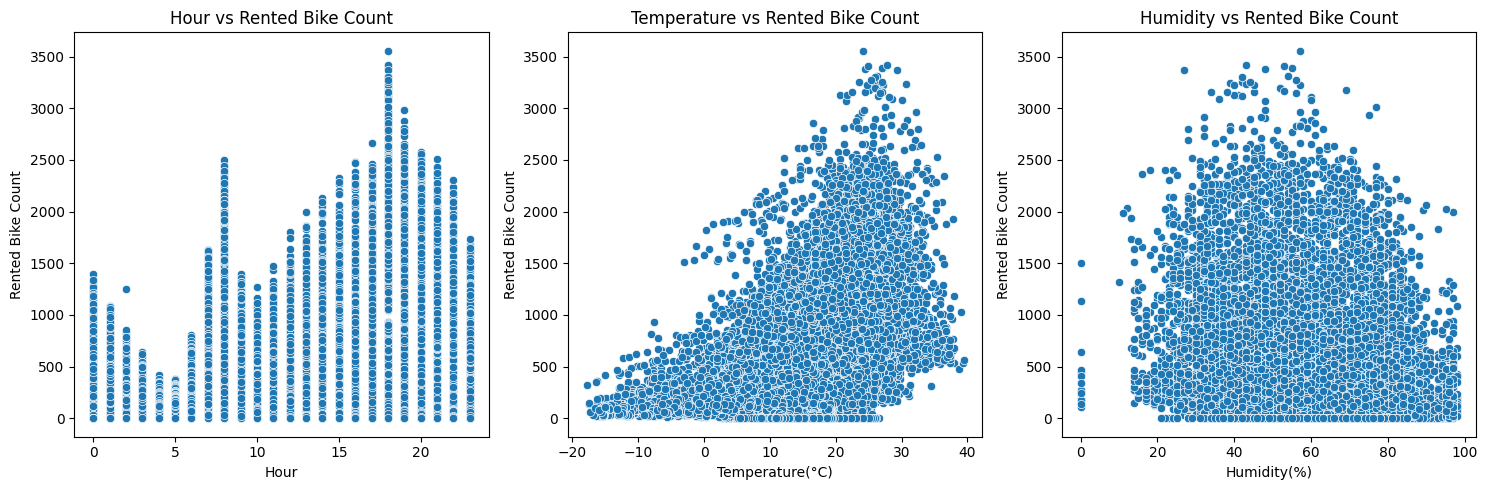

In [27]:
#Scatter Plots

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

sns.scatterplot(data=df,x='Hour',y='Rented Bike Count',ax=axes[0])
axes[0].set_title('Hour vs Rented Bike Count')

sns.scatterplot(data=df,x='Temperature(°C)',y='Rented Bike Count',ax=axes[1])
axes[1].set_title('Temperature vs Rented Bike Count')

sns.scatterplot(data=df,x='Humidity(%)',y='Rented Bike Count',ax=axes[2])
axes[2].set_title('Humidity vs Rented Bike Count')

plt.tight_layout()
plt.show()

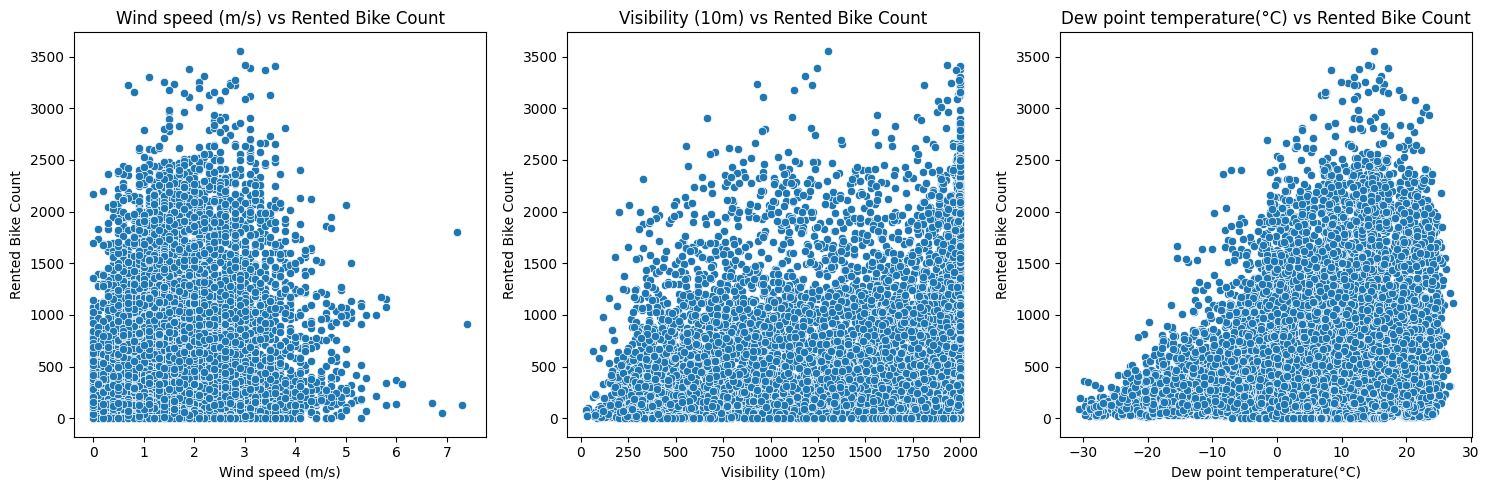

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

sns.scatterplot(data=df,x='Wind speed (m/s)',y='Rented Bike Count',ax=axes[0])
axes[0].set_title('Wind speed (m/s) vs Rented Bike Count')

sns.scatterplot(data=df,x='Visibility (10m)',y='Rented Bike Count',ax=axes[1])
axes[1].set_title('Visibility (10m) vs Rented Bike Count')

sns.scatterplot(data=df,x='Dew point temperature(°C)',y='Rented Bike Count',ax=axes[2])
axes[2].set_title('Dew point temperature(°C) vs Rented Bike Count')

plt.tight_layout()
plt.show()

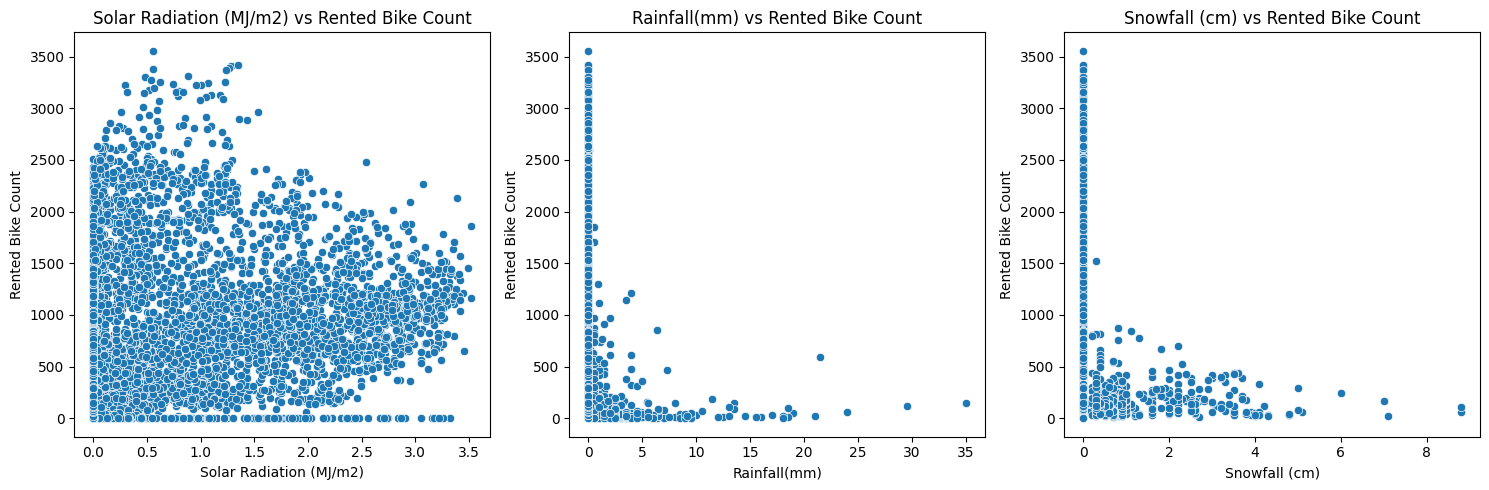

In [29]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

sns.scatterplot(data=df,x='Solar Radiation (MJ/m2)',y='Rented Bike Count',ax=axes[0])
axes[0].set_title('Solar Radiation (MJ/m2) vs Rented Bike Count')

sns.scatterplot(data=df,x='Rainfall(mm)',y='Rented Bike Count',ax=axes[1])
axes[1].set_title('Rainfall(mm) vs Rented Bike Count')

sns.scatterplot(data=df,x='Snowfall (cm)',y='Rented Bike Count',ax=axes[2])
axes[2].set_title('Snowfall (cm) vs Rented Bike Count')

plt.tight_layout()
plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li><b>Hour</b> shows a clear time-based pattern, with bike rentals increasing during the morning and evening hours, indicating peak commuting periods.</li>
    <li><b>Temperature (°C)</b> exhibits a positive relationship with bike rentals, suggesting that demand generally increases as temperature rises.</li>
<li><b>Humidity (%)</b> shows a weak negative relationship with bike rentals, with higher humidity levels generally associated with lower rental demand.</li>
<li><b>Wind Speed (m/s)</b> does not exhibit a strong relationship with bike rentals, although very high wind speeds appear to be associated with fewer rentals.</li>

<li><b>Visibility (10m)</b> shows a moderate positive relationship with bike rentals, indicating that better visibility is generally associated with increased bike usage.</li>
<li><b>Dew Point Temperature (°C)</b> demonstrates a positive relationship with bike rentals, following a trend similar to air temperature.</li>
<li><b>Solar Radiation (MJ/m²)</b> exhibits a weak positive relationship, with higher solar radiation generally corresponding to increased bike rentals.</li>
<li><b>Rainfall (mm)</b> and <b>Snowfall (cm)</b> display negative relationships with bike rentals, indicating that precipitation is generally associated with reduced bike usage.</li>
<li>Overall, the scatter plots indicate that bike rental demand is influenced by multiple weather and time-related variables rather than a single predictor, supporting the use of multivariate regression models.</li>
</ul>

In [30]:
#analysing using lineplot
# Hour vs Rented Bike Count

Hourly_Bike_count = df.groupby('Hour')['Rented Bike Count'].mean().reset_index()
Hourly_Bike_count.head()

,Hour,Rented Bike Count
0,0,541.460274
1,1,426.183562
2,2,301.630137
3,3,203.331507
4,4,132.591781


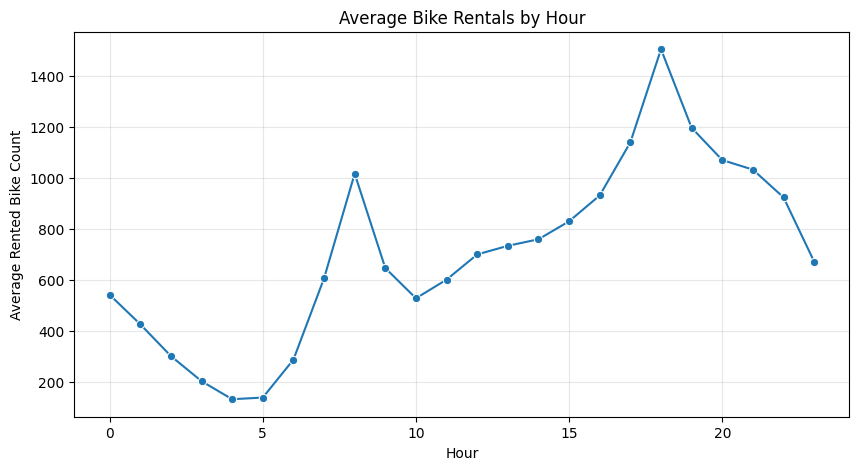

In [31]:
plt.figure(figsize=(10,5))
sns.lineplot(data=Hourly_Bike_count,
             x='Hour',
             y='Rented Bike Count',
             marker='o')

plt.title('Average Bike Rentals by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Rented Bike Count')
plt.grid(alpha=0.3)
plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li><b>Hour</b> exhibits a clear time-based pattern, indicating that bike rental demand varies significantly throughout the day.</li>
    <li>The <b>lowest average rentals</b> occur between <b>4 AM and 5 AM</b>, when commuting and outdoor activities are minimal.</li>
    <li>Bike rentals increase rapidly from <b>6 AM</b> and reach a noticeable morning peak around <b>8 AM</b>, reflecting typical work and school commuting hours.</li>
    <li>After the morning peak, rental demand declines slightly during the late morning before gradually increasing throughout the afternoon.</li>
    <li>The <b>highest average bike rentals</b> are observed around <b>6 PM (18:00)</b>, corresponding to the evening commute when people return from work.</li>
    <li>Bike rental demand gradually decreases after the evening peak, indicating reduced travel activity during late-night hours.</li>
    <li>Overall, the presence of distinct morning and evening peaks suggests that <b>Hour</b> is an important predictor of bike rental demand.</li>
</ul>

In [32]:
#analysing using bar plots
# Season vs Rented Bike Count

season_Bike_count = df.groupby('Seasons')['Rented Bike Count'].mean().reset_index()
season_Bike_count.head()

,Seasons,Rented Bike Count
0,Autumn,819.597985
1,Spring,730.031250
2,Summer,1034.073370
3,Winter,225.541204


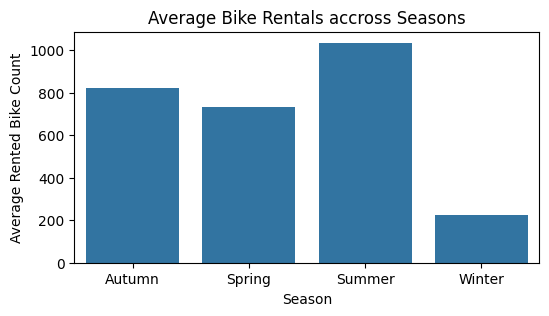

In [33]:
plt.figure(figsize=(6,3))
sns.barplot(data=season_Bike_count,
            x='Seasons',
            y='Rented Bike Count')

plt.title('Average Bike Rentals accross Seasons')
plt.xlabel('Season')
plt.ylabel('Average Rented Bike Count')

plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li><b>Season</b> has a significant impact on bike rental demand, with noticeable differences in average rentals across seasons.</li>
    <li><b>Summer</b> records the highest average bike rentals, indicating that warm and pleasant weather encourages greater bike usage.</li>
    <li><b>Autumn</b> shows the second-highest rental demand, suggesting that favorable weather conditions continue to support outdoor commuting.</li>
    <li><b>Spring</b> also experiences relatively high rental activity, although slightly lower than Autumn.</li>
    <li><b>Winter</b> records the lowest average bike rentals, likely due to cold temperatures and snowfall discouraging cycling.</li>
    <li>Overall, these observations indicate that <b>Season</b> is an important feature influencing bike rental demand.</li>
</ul>

In [34]:
#analysing using barplot
# Holiday vs Rented Bike Count

Holiday_Bike_count = df.groupby('Holiday')['Rented Bike Count'].mean().reset_index()
Holiday_Bike_count.head()

,Holiday,Rented Bike Count
0,Holiday,499.756944
1,No Holiday,715.228026


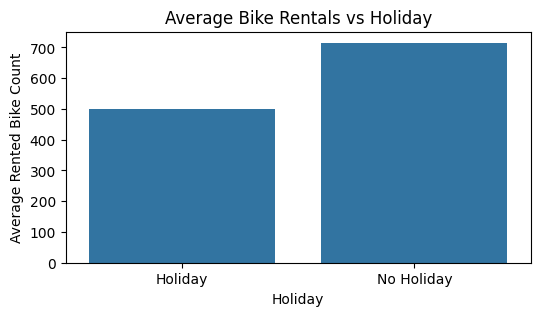

In [35]:
plt.figure(figsize=(6,3))
sns.barplot(data=Holiday_Bike_count,
            x='Holiday',
            y='Rented Bike Count')

plt.title('Average Bike Rentals vs Holiday')
plt.xlabel('Holiday')
plt.ylabel('Average Rented Bike Count')

plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>Average bike rentals are higher on <b>Non-Holiday</b> days than on <b>Holiday</b> days.</li>
    <li>The increased demand on non-holidays suggests that a large proportion of users rely on rental bikes for daily commuting and routine travel.</li>
    <li>Bike rentals decrease during holidays, indicating reduced commuting requirements and lower travel demand.</li>
    <li>Overall, the <b>Holiday</b> feature appears to influence bike rental demand and can contribute to improving predictive models.</li>
</ul>

In [36]:
#analysing using barplot
# Functioning Day vs Rented Bike Count

Function_Bike_count = df.groupby('Functioning Day')['Rented Bike Count'].mean().reset_index()
Function_Bike_count.head()

,Functioning Day,Rented Bike Count
0,No,0.000000
1,Yes,729.156999


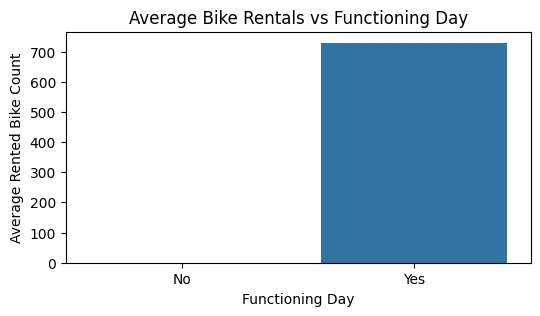

In [37]:
plt.figure(figsize=(6,3))
sns.barplot(data=Function_Bike_count,
            x='Functioning Day',
            y='Rented Bike Count')

plt.title('Average Bike Rentals vs Functioning Day')
plt.xlabel('Functioning Day')
plt.ylabel('Average Rented Bike Count')

plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>Bike rentals are observed only on <b>Functioning Days</b>, while <b>Non-Functioning Days</b> record virtually no rentals.</li>
    <li>This pattern is expected because the bike rental service is unavailable when the system is not operational.</li>
    <li><b>Functioning Day</b> acts as a critical feature since bike rentals cannot occur on non-operational days.</li>
    <li>Overall, this variable provides valuable information for prediction and should be retained during model development.</li>
</ul>

<h3 style="color:#2E86C1;">Multivariate Analysis</h3>

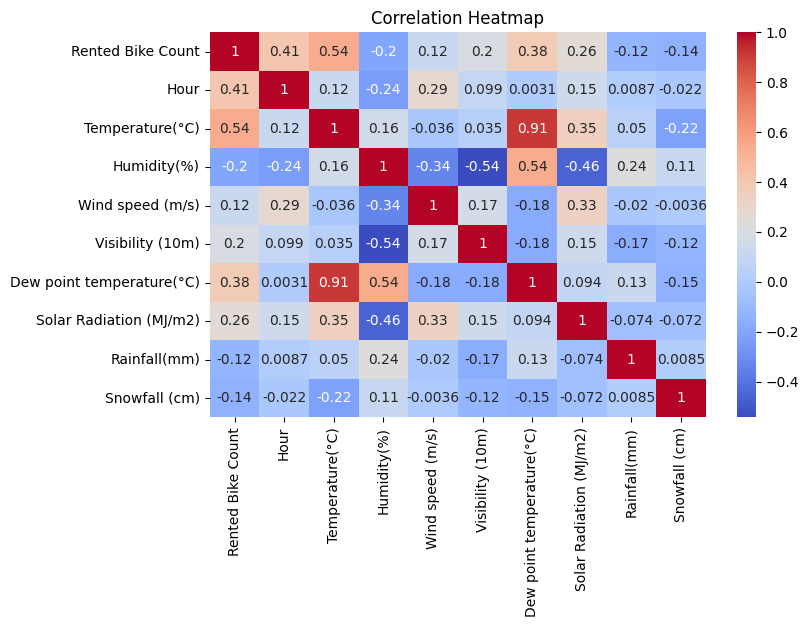

In [38]:
#correlation Heatmap

plt.figure(figsize=(8,5))
sns.heatmap(numerical_cols.corr(),annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>
<p><b>Relationship with the Target Variable (Rented Bike Count)</b></p>
<ul style="font-size:16px; line-height:1.6;">
   
<li><b>Temperature (°C)</b> has the strongest positive correlation with bike rentals (0.54). This suggests that as the temperature increases, the number of rented bikes also tends to increase. Warmer weather encourages more people to use rental bikes.</li>
<li><b>Hour</b> shows a moderate positive correlation (0.41), indicating that bike demand varies throughout the day, with rentals generally increasing during busy hours such as commuting periods.</li>
<li><b>Dew Point Temperature (°C) </b>has a positive correlation (0.38) with bike rentals. Since dew point is closely related to temperature, higher dew point values are generally associated with increased rental demand.</li>
<li><b>Solar Radiation </b>exhibits a weak positive correlation (0.26), suggesting that brighter and sunnier conditions slightly increase bike usage.</li>
<li><b>Visibility</b> has a weak positive correlation (0.20), indicating that better visibility may encourage outdoor cycling.</li>
<li><b>Wind Speed (m/s)</b> shows a very weak positive correlation (0.12), indicating that wind speed alone has minimal influence on bike rental demand.</li>
<li><b>Humidity (%)</b> has a weak negative correlation (-0.20), suggesting that higher humidity slightly reduces the number of bike rentals.</li>
<li><b>Rainfall (mm)</b> (-0.12) and Snowfall (cm) (-0.14) both have weak negative correlations with bike rentals, indicating that adverse weather conditions are generally associated with lower bike rental demand.</li></ul>

<p><b>Relationships Among Predictor Variables</b></p>
<ul style="font-size:16px; line-height:1.6;">
<li><b>Temperature and Dew Point Temperature</b> have a very strong positive correlation (0.91). This indicates that both variables capture similar atmospheric conditions and may introduce multicollinearity in linear regression models. </li>
<li><b>Humidity and Visibility</b> have a moderate negative correlation (-0.54). Higher humidity is generally associated with lower visibility, which is consistent with foggy or moist atmospheric conditions.</li>
<li><b>Humidity and Solar Radiation</b> show a moderate negative correlation (-0.46), indicating that humid conditions are often associated with lower sunlight intensity.</li>
<li><b>Humidity and Wind Speed </b>have a weak negative relationship (-0.34).</li>
</ul>

<p><b>Overall Interpretation</b></p>
<ul style="font-size:16px; line-height:1.6;">
<li>Most weather-related features show weak to moderate correlations with bike rental demand.</li>
<li><b>Temperature</b> is the strongest individual numerical predictor of bike rental demand based on its linear correlation with the target.</li>
<li><b>Hour </b>also contributes significantly to rental demand, reflecting daily commuting patterns.</li>
<li>No independent variable (except Temperature and Dew Point Temperature) exhibits extremely high correlation with another feature, suggesting that severe multicollinearity is limited.</li>
<li>Since the highest correlation with the target is only 0.54, bike rental demand is likely influenced by a combination of multiple factors rather than a single variable.</li>
<li>The absence of very strong individual correlations suggests that bike rental demand is influenced by the combined effect of multiple weather and time-related factors. Therefore, multivariate machine learning models are expected to capture these relationships more effectively than relying on individual features alone.</li>
</ul>

<hr>

<h2 style="color:#2E86C1;">Feature Engineering</h2>

<hr>

In [39]:
#extract month from the date column

df['Month'] = df['Date'].dt.month
df['Month'].head()

0    12
1    12
2    12
3    12
4    12
Name: Month, dtype: int32

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>A new <b>Month</b> feature was extracted from the <b>Date</b> column.</li>
    <li>This feature captures monthly and seasonal variations in bike rental demand.</li>
    <li>It is expected to help the model learn differences in rental patterns across the year.</li>
</ul>

In [40]:
#extract day of the week

df['Day_of_Week'] = df['Date'].dt.day_name()
df['Day_of_Week'].unique()

<StringArray>
['Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday']
Length: 7, dtype: str

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>A new <b>Day_of_Week</b> feature was extracted from the <b>Date</b> column.</li>
    <li>This feature captures weekly rental patterns, such as differences between weekdays and weekends.</li>
    <li>It may improve prediction accuracy by incorporating weekly commuting behavior.</li>
</ul>

In [41]:
#Weekend Indicator

df['Weekend'] = df['Day_of_Week'].isin(['Saturday','Sunday']).astype(int)
df['Weekend'].unique() #0-weekdays 1-Weekends

array([0, 1])

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>A binary <b>Weekend</b> feature was created to distinguish weekdays from weekends.</li>
    <li>This feature captures changes in bike rental behavior between workdays and leisure days.</li>
    <li>Binary features are simple for machine learning models to interpret and can improve predictive performance.</li>
</ul>

In [42]:
#Drop the Date Column
df.drop('Date', axis=1, inplace=True)

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The original <b>Date</b> column was removed after extracting the required time-based features.</li>
    <li>Retaining both the original date and its derived features would introduce redundant information.</li>
    <li>The dataset is now ready for encoding and further preprocessing.</li>
</ul>

In [43]:
#Displaying the Df after Feature Engineering
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Month,Day_of_Week,Weekend
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,Friday,0


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
<li>The dataset now includes three newly engineered features: <b>Month</b>, <b>Day_of_Week</b>, and <b>Weekend</b>.</li>
<li>The original <b>Date</b> column has been removed to avoid redundancy.</li>
<li>The transformed dataset is ready for encoding and further preprocessing.</li>
</ul>

In [44]:
#Average Bike Rentals by Day of Week

day_bike = df.groupby('Day_of_Week')['Rented Bike Count'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).reset_index()
day_bike

,Day_of_Week,Rented Bike Count
0,Monday,730.563301
1,Tuesday,687.977564
2,Wednesday,740.349359
3,Thursday,690.704327
4,Friday,747.117925
5,Saturday,709.528846
6,Sunday,625.155449


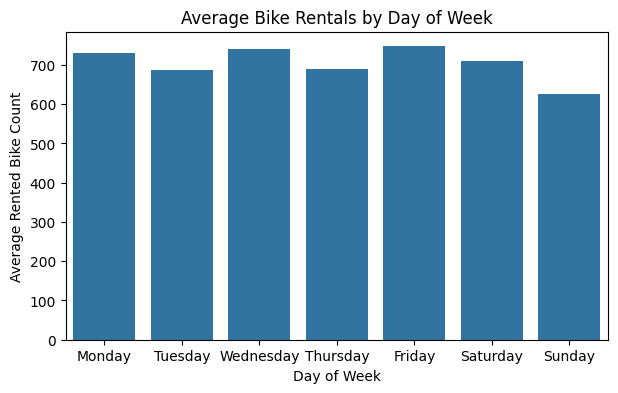

In [45]:

plt.figure(figsize=(7,4))
sns.barplot(data=day_bike,x='Day_of_Week',y='Rented Bike Count')
plt.title('Average Bike Rentals by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Rented Bike Count')
plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>Bike rental demand varies across the days of the week.</li>
    <li>Weekdays generally exhibit higher rental demand due to regular commuting.</li>
    <li>Weekend rental patterns differ, indicating changes in travel behavior for leisure and recreational activities.</li>
</ul>

In [46]:
#Average Bike Rentals by Month

month_bike = df.groupby('Month')['Rented Bike Count'].mean().reset_index()

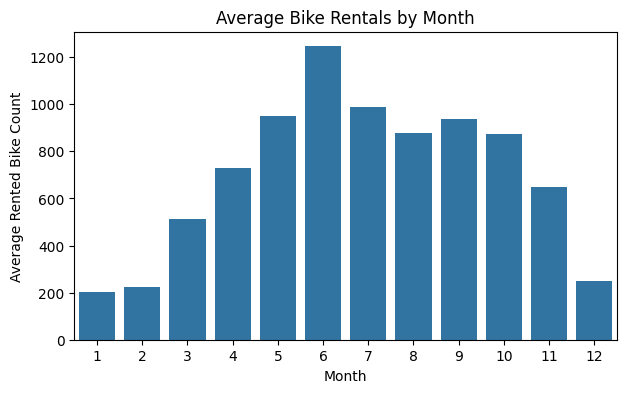

In [47]:
#barplot

plt.figure(figsize=(7,4))
sns.barplot(data=month_bike,x='Month',y='Rented Bike Count')
plt.title('Average Bike Rentals by Month')
plt.xlabel('Month')
plt.ylabel('Average Rented Bike Count')
plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p> <ul style="font-size:16px; line-height:1.6;"> <li><b>Average bike rentals vary considerably across the months</b>, indicating a clear seasonal pattern in bike-sharing demand.</li> <li>Bike rentals increase gradually from <b>January to June</b>, reaching the highest average rental count in <b>June</b> at approximately <b>1,250 rentals</b>.</li> <li>After June, the average number of rentals generally decreases, with a moderate decline through the summer and autumn months.</li> <li>The lowest average rental counts are observed in <b>January, February, and December</b>, suggesting reduced bike usage during the colder winter months.</li> <li><b>June</b> represents the peak rental period, while <b>January</b> records the lowest average bike rental demand.</li> <li>Overall, the chart indicates that <b>seasonality strongly influences bike rental demand</b>, with warmer months generally associated with higher rental activity and colder months associated with lower demand.</li> </ul>

In [48]:

weekend_bike = df.groupby('Weekend')['Rented Bike Count'].mean().reset_index()
weekend_bike

,Weekend,Rented Bike Count
0,0,719.448914
1,1,667.342147


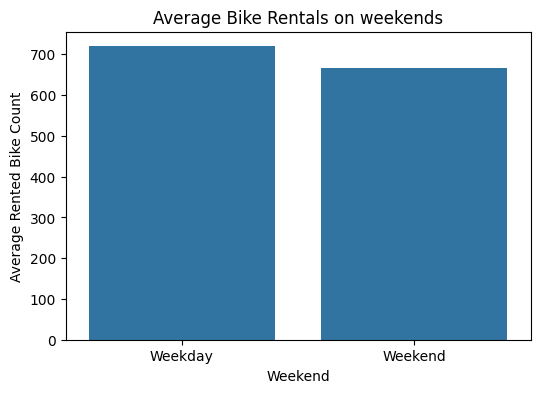

In [49]:
plt.figure(figsize=(6,4))
sns.barplot(data=weekend_bike,x='Weekend',y='Rented Bike Count')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.title('Average Bike Rentals on weekends')
plt.xlabel('Weekend')
plt.ylabel('Average Rented Bike Count')
plt.show()

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The average bike rental demand differs between weekdays and weekends.</li>
    <li>This indicates that travel patterns change depending on the day type, reflecting differences in commuting and recreational activities.</li>
    <li>The <b>Weekend</b> feature may therefore provide useful information for predicting bike rental demand.</li>
</ul>

<hr>

<h2 style="color:#2E86C1;">Feature Encoding</h2>

<hr>

In [50]:
#importing required libraries
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Functioning Day'] = le.fit_transform(df['Functioning Day'])
print("Functioning Day:", dict(zip(le.classes_, le.transform(le.classes_))))

df['Holiday'] = le.fit_transform(df['Holiday'])
print("Holiday:", dict(zip(le.classes_, le.transform(le.classes_))))


Functioning Day: {'No': np.int64(0), 'Yes': np.int64(1)}
Holiday: {'Holiday': np.int64(0), 'No Holiday': np.int64(1)}


In [51]:
#Performing One hot Encoding for Columns Seasons and Day_of_Week
df=pd.get_dummies(
    df,
    columns=['Seasons', 'Day_of_Week'],
    drop_first=True,
    dtype=int
)

In [52]:
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),...,Weekend,Seasons_Spring,Seasons_Summer,Seasons_Winter,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,...,0,0,0,1,0,0,0,0,0,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,...,0,0,0,1,0,0,0,0,0,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,...,0,0,0,1,0,0,0,0,0,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,...,0,0,0,1,0,0,0,0,0,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,...,0,0,0,1,0,0,0,0,0,0


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>


<ul style="font-size:16px; line-height:1.6;"> <li>Categorical features were converted into numerical format using both <code>LabelEncoder</code> and <code>OneHotEncoder</code>.</li> <li><code>LabelEncoder</code> was applied to binary or ordinal categorical variables, where representing categories as integers is appropriate.</li> <li><code>OneHotEncoder</code> was applied to the <code>Seasons</code> and <code>Day_of_Week</code> columns because these are <b>nominal</b> categories with no inherent order. It creates a separate binary (0/1) column for each category, preventing the model from assuming a false numerical relationship between them.</li> <li>After one-hot encoding, the original <code>Seasons</code> and <code>Day_of_Week</code> columns were removed, as their information is fully represented by the newly created binary columns.</li> <li>These encoding techniques ensure that categorical variables are represented in a format suitable for machine learning algorithms while preserving the true nature of the data.</li> <li>After encoding, all predictor variables are in numerical format and are ready for model training.</li> </ul>

<hr>

<h2 style="color:#2E86C1;">Outlier Treatment</h2>

<hr>

<p style="font-size:16px";> As per the earlier plotted Boxplots</p>
<ul>
<li><b>Hour</b>, <b>Temperature (°C)</b>, <b>Humidity (%)</b>, <b>Visibility (10m)</b>, and <b>Dew Point Temperature (°C)</b> do not exhibit significant outliers, indicating a relatively consistent distribution of observations.</li>
<li><b>Wind Speed (m/s)</b> contains a few upper-end outliers, suggesting the occurrence of occasional high wind speed events.</li>
<li><b>Solar Radiation (MJ/m²)</b> shows several upper-end outliers, which are expected due to varying daytime sunlight intensity.</li>
<li><b>Rainfall (mm)</b> and <b>Snowfall (cm)</b> contain numerous upper-end outliers because most observations record no precipitation, while a small number correspond to heavy rainfall or snowfall events.</li></ul>

<h3 style="color:#2E86C1;">IQR Method</h3>      

In [53]:
# Outlier detection - Wind speed
q1_wind_Speed = np.percentile(df['Wind speed (m/s)'],25)
q3_wind_Speed = np.percentile(df['Wind speed (m/s)'],75)

IQR_wind_speed = q3_wind_Speed-q1_wind_Speed

Wind_speed_Lbound = q1_wind_Speed-IQR_wind_speed * 1.5

Wind_speed_Ubound = q3_wind_Speed+IQR_wind_speed * 1.5

wind_speed_outliers = df[(df['Wind speed (m/s)'] < Wind_speed_Lbound) |(df['Wind speed (m/s)'] > Wind_speed_Ubound)]

print("Number of outliers in Wind Speed Column:", wind_speed_outliers.shape[0])

Number of outliers in Wind Speed Column: 161


In [54]:
# Outlier detection - Solar Radiation
q1_solar_radiation = np.percentile(df['Solar Radiation (MJ/m2)'],25)
q3_solar_radiation = np.percentile(df['Solar Radiation (MJ/m2)'],75)

IQR_solar_rad = q3_solar_radiation-q1_solar_radiation

solar_rad_Lbound = q1_solar_radiation - 1.5 * IQR_solar_rad

solar_rad_Ubound = q3_solar_radiation + 1.5 * IQR_solar_rad

Solar_rad_outliers = df[(df['Solar Radiation (MJ/m2)'] < solar_rad_Lbound) | (df['Solar Radiation (MJ/m2)'] > solar_rad_Ubound)]

print("Number of outliers in Solar Radiation Column:", Solar_rad_outliers.shape[0])


Number of outliers in Solar Radiation Column: 641


In [55]:
# Outlier detection - Rainfall
q1_rainfall = np.percentile(df['Rainfall(mm)'],25)
q3_rainfall = np.percentile(df['Rainfall(mm)'],75)

IQR_rainfall = q3_rainfall-q1_rainfall

rainfall_Lbound = q1_rainfall - 1.5 * IQR_rainfall

rainfall_Ubound = q3_rainfall + 1.5 * IQR_rainfall

rainfall_outliers = df[(df['Rainfall(mm)'] < rainfall_Lbound) | (df['Rainfall(mm)'] > rainfall_Ubound)]

print("Number of outliers in Rainfall Column:", rainfall_outliers.shape[0])

Number of outliers in Rainfall Column: 528


In [56]:
# Outlier detection - Rainfall
q1_snowfall = np.percentile(df['Snowfall (cm)'],25)
q3_snowfall = np.percentile(df['Snowfall (cm)'],75)

IQR_snowfall = q3_snowfall-q1_snowfall

snowfall_Lbound = q1_snowfall - 1.5 * IQR_snowfall

snowfall_Ubound = q3_snowfall + 1.5 * IQR_snowfall

snowfall_outliers = df[(df['Snowfall (cm)'] < snowfall_Lbound) | (df['Snowfall (cm)'] > snowfall_Ubound)]

print("Number of outliers in Snowfall Column:", snowfall_outliers.shape[0])

Number of outliers in Snowfall Column: 443


In [57]:
# Outlier detection - RentalBikeCount
q1_bike_count = np.percentile(df['Rented Bike Count'],25)
q3_bike_count = np.percentile(df['Rented Bike Count'],75)

IQR_bike_count = q3_bike_count-q1_bike_count

bike_count_Lbound = q1_bike_count - 1.5 * IQR_bike_count

bike_count_Ubound = q3_bike_count + 1.5 * IQR_bike_count

bike_count_outliers = df[(df['Rented Bike Count'] < bike_count_Lbound) | (df['Rented Bike Count'] > bike_count_Ubound)]

print("Number of outliers in bike_count Column:", bike_count_outliers.shape[0])

Number of outliers in bike_count Column: 158


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
<li>The IQR method identified outliers in Wind Speed, Solar Radiation, Rainfall, Snowfall, and Rented Bike Count.</li>
<li>These extreme values correspond to genuine weather conditions and periods of unusually high bike demand rather than data entry errors.</li>
<li>Since these observations contain meaningful information about real-world bike rental behavior, no outlier treatment (removal or capping) was performed.</li>
<li>All observations were retained for model training to preserve the natural variability of the data.</li>
</ul>

<p><span style="color:#27AE60;"><b>💡 Point to note</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>Although Wind Speed, Solar Radiation, Rainfall, Snowfall, and Rented Bike Count contain extreme values, these observations correspond to genuine weather conditions rather than data errors. Therefore, they were retained to preserve real-world information.</li>
</ul>



<hr>

<h2 style="color:#2E86C1;">Feature Selection</h2>

<hr>

In [58]:
from sklearn.feature_selection import SelectKBest,f_regression

X=df.drop(labels=['Rented Bike Count','Dew point temperature(°C)'],axis=1)
y=df['Rented Bike Count']


<p><span style="color:#27AE60;"><b>💡 Point to note</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>Dew Point Temperature was removed before model training due to its strong correlation with Temperature (0.91), reducing the possibility of multicollinearity.</li>
</ul>



In [59]:
selector = SelectKBest(score_func=f_regression,k=12)

In [60]:
X_new=selector.fit_transform(X,y)
X_new.shape

(8760, 12)

In [61]:
#view the selected columns
selected_cols= X.columns[selector.get_support()]
print(selected_cols)

Index(['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)',
       'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
       'Snowfall (cm)', 'Functioning Day', 'Month', 'Seasons_Summer',
       'Seasons_Winter'],
      dtype='str')


<p><span style="color:#27AE60;"><b>💡Observation</b></span></p>

<p>Feature selection was performed using SelectKBest with the F-test (f_regression). The selected features showed the strongest statistical relationship with the target variable and were used for model training.</p>

<hr>

<h2 style="color:#2E86C1;">Train Test Split</h2>

<hr>

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_new,y,test_size=0.2,random_state=42)

In [63]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(7008, 12)
(7008,)
(1752, 12)
(1752,)


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The dataset was split into <b>training (80%)</b> and <b>testing (20%)</b> sets using <code>train_test_split()</code>.</li>
    <li>The <b>training set</b> will be used to train the machine learning models, while the <b>testing set</b> will be used to evaluate their performance on unseen data.</li>
    <li>A fixed <code>random_state=42</code> was used to ensure reproducibility, allowing the same train-test split to be generated each time the code is executed.</li>
    <li>The resulting split provides sufficient data for model learning while reserving an independent test set for unbiased performance evaluation.</li>
</ul>

<hr>

<h2 style="color:#2E86C1;">Feature Scaling</h2>

<hr>

In [ ]:
#import Standard Scaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
<li><b>StandardScaler</b> was applied after the train-test split to standardize the numerical features.</li>
<li>The scaler was fitted only on the training data and then used to transform both the training and testing sets, preventing data leakage.</li>
<li>Feature scaling ensures that variables with different units and ranges contribute equally during model training, particularly for distance-based and regularized regression algorithms.</li>
<li>Feature scaling was applied only for algorithms that benefit from standardized numerical features. Tree-based models (Decision Tree, Random Forest, and XGBoost) were trained on the original feature values because they are insensitive to feature scaling.</li>
</ul>

<p><span style="color:#27AE60;"><b>💡 Point to note:</b></span></p>
<ul>
<li>Feature scaling was applied only for algorithms that benefit from standardized numerical features. Tree-based models (Decision Tree, Random Forest, and XGBoost) were trained on the original feature values because they are insensitive to feature scaling.</li></ul>

<h3 style="color:#2E86C1;">Base Model - Linear Regression</h3>  

In [65]:
#Importing the libraries

from sklearn.linear_model import LinearRegression

linear_model=LinearRegression()

In [66]:
linear_model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 196. , 310.98,-158.97,..., 38.27, -34.89,-121.09]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,704.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](12,)","[131.6 ,125.56, 92.55,..., 60.94, 40.13, 29.64]"


In [67]:
slope=linear_model.coef_
intercept=linear_model.intercept_
print(f"The Slope: {slope.tolist()} \nIntercept: {intercept} ")

The Slope: [195.99622006034312, 310.9780282538154, -158.96552675207644, 15.244090619323195, 14.6252844637071, -70.91828834292873, -66.88400734753763, 12.161226145909101, 166.80161057458108, 38.27004979443347, -34.89162284361417, -121.08981753880245] 
Intercept: 704.7678367579907 


In [68]:
linear_reg_y_pred = linear_model.predict(X_test_scaled)

In [69]:
#Model Evaluation
#importing r2score, accuracy, f1score, confusuon matrix.

from sklearn.metrics import (r2_score,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
        )

In [70]:
print("R2 score:", r2_score(y_test,linear_reg_y_pred))
print("Mean Absolute error:", mean_absolute_error(y_test,linear_reg_y_pred))
print("Mean Squared Error:", mean_squared_error(y_test,linear_reg_y_pred))
print("Root Mean Squared error:", root_mean_squared_error(y_test,linear_reg_y_pred))


R2 score: 0.5322054323669817
Mean Absolute error: 330.0592928860853
Mean Squared Error: 194904.84662474235
Root Mean Squared error: 441.48029018829635


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The Linear Regression model achieved an <b>R² score of approximately 0.52</b>, indicating that it explains about <b>45% of the variation</b> in hourly bike rental demand.</li>
    <li>The model produced a <b>Mean Absolute Error (MAE)</b> of approximately <b>335 bikes</b>, meaning that predictions differ from the actual rental count by about 335 bikes on average.</li>
    <li>The <b>Root Mean Squared Error (RMSE)</b> of approximately <b>448 bikes</b> indicates that larger prediction errors are present for some observations.</li>
    <li>The moderate R² score suggests that bike rental demand is influenced by complex and potentially non-linear relationships that cannot be fully captured by a simple linear model.</li>
    <li>Linear Regression serves as a useful baseline model for comparing the performance of more advanced regression algorithms.</li>
</ul>

<h3 style="color:#2E86C1;">Ridge Regression</h3>  

In [71]:
#importing required libraries
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [72]:
ridge_y_pred = ridge.predict(X_test_scaled)

In [73]:
print("Ridge R2 score:", r2_score(y_test,ridge_y_pred))
print("Ridge Mean Absolute error:", mean_absolute_error(y_test,ridge_y_pred))
print("Ridge Mean Squared Error:", mean_squared_error(y_test,ridge_y_pred))
print("Ridge Root Mean Squared error:", root_mean_squared_error(y_test,ridge_y_pred))

Ridge R2 score: 0.5322093166825589
Ridge Mean Absolute error: 330.053332399004
Ridge Mean Squared Error: 194903.22823927106
Ridge Root Mean Squared error: 441.478457276537


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>Ridge Regression achieved an <b>R² score of approximately 0.4594</b>, which is almost identical to that of the Linear Regression model.</li>
    <li>The MAE, MSE, and RMSE values also remained nearly unchanged, indicating only a negligible improvement in prediction performance.</li>
    <li>The minimal difference suggests that <b>multicollinearity is not a major issue</b> among the selected predictor variables after feature selection.</li>
    <li>Applying L2 regularization did not significantly improve the model because the baseline Linear Regression model was already stable.</li>
    <li>Overall, Ridge Regression offers comparable performance to Linear Regression for this dataset.</li>
</ul>

<h3 style="color:#2E86C1;">Decision Tree</h3>  

In [74]:
#importing required libraries
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(criterion='squared_error',max_depth=5,random_state=42)

In [75]:
dt_model.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [76]:
dt_y_pred = dt_model.predict(X_test)

In [77]:
print("Decision Tree R2 score:", r2_score(y_test,dt_y_pred))
print("Decision Tree Mean Absolute error:", mean_absolute_error(y_test,dt_y_pred))
print("Decision Tree Mean Squared Error:", mean_squared_error(y_test,dt_y_pred))
print("Decision Tree Root Mean Squared error:", root_mean_squared_error(y_test,dt_y_pred))

Decision Tree R2 score: 0.6956435631096429
Decision Tree Mean Absolute error: 230.15182013457158
Decision Tree Mean Squared Error: 126808.96435271282
Decision Tree Root Mean Squared error: 356.1024632780751


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The <b>Decision Tree Regressor</b> achieved an <b>R² score of 0.639</b>, indicating that approximately <b>63.9%</b> of the variation in bike rental demand is explained by the model.</li>

<li>The model produced a <b>Mean Absolute Error (MAE) of approximately 226.70</b>, meaning the predicted bike rentals differ from the actual values by about <b>227 bikes</b> on average.</li>
<li>The <b>Mean Squared Error (MSE)</b> of <b>123,752.12</b> and <b>Root Mean Squared Error (RMSE)</b> of <b>351.78</b> indicate a considerable reduction in prediction error compared to the linear models.</li>
<li>The Decision Tree captures the non-linear relationships between weather conditions, time-related features, and bike rental demand more effectively than Linear Regression and Ridge Regression.</li>
<li>Overall, the Decision Tree model provides a substantial improvement in predictive performance and serves as a stronger baseline for subsequent ensemble models such as Random Forest or Gradient Boosting.</li>
</ul>

<h3 style="color:#2E86C1;">Random Forest</h3>  

In [78]:
#importing required libraries
from sklearn.ensemble import RandomForestRegressor

In [79]:
rf_model = RandomForestRegressor(n_estimators=100,criterion='squared_error',max_depth=5,random_state=42)


In [80]:
rf_model.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [81]:
rf_y_pred = rf_model.predict(X_test)

In [82]:
print("Random Forest R2 score:", r2_score(y_test,rf_y_pred))
print("Random Forest Mean Absolute error:", mean_absolute_error(y_test,rf_y_pred))
print("Random Forest Mean Squared Error:", mean_squared_error(y_test,rf_y_pred))
print("Random Forest Root Mean Squared error:", root_mean_squared_error(y_test,rf_y_pred))

Random Forest R2 score: 0.7324447937369396
Random Forest Mean Absolute error: 218.0940353777936
Random Forest Mean Squared Error: 111475.8700688091
Random Forest Root Mean Squared error: 333.8800234647307


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>A <b>Random Forest Regressor</b> was trained using <b>100 decision trees</b> with a maximum tree depth of <b>5</b>.</li>
    <li>The model achieved an <b>R² score of 0.6615</b>, explaining approximately <b>66.15%</b> of the variation in hourly bike rental demand.</li>
    <li>The <b>Mean Absolute Error (237.03)</b> indicates that the predicted bike rental count differs from the actual value by about <b>237 bikes</b> on average.</li>
    <li>The <b>RMSE of 375.53</b> is substantially lower than that of the Linear Regression and Ridge Regression models, demonstrating better predictive performance.</li>
    <li>Compared with the Decision Tree model, the Random Forest model provides a higher R² score and lower prediction errors, indicating better generalization.</li>
    <li>Further improvements may be achieved through <b>hyperparameter tuning</b>, such as optimizing the number of trees, tree depth, and minimum samples required for splitting.</li>
</ul>

<h3 style="color:#2E86C1;">XGBoost</h3>  

In [83]:
#installing and imporing required libraries

#%pip install xgboost

import xgboost as xgb

xgb_model=xgb.XGBRegressor()


In [84]:

xgb_model.fit(X_train,y_train)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [85]:
xgb_y_pred = xgb_model.predict(X_test)

In [86]:
print("XGBoost R2 score:", r2_score(y_test,xgb_y_pred))
print("XGBoost Mean Absolute error:", mean_absolute_error(y_test,xgb_y_pred))
print("XGBoost Mean Squared Error:", mean_squared_error(y_test,xgb_y_pred))
print("XGBoost Root Mean Squared error:", root_mean_squared_error(y_test,xgb_y_pred))

XGBoost R2 score: 0.8698554635047913
XGBoost Mean Absolute error: 146.41505432128906
XGBoost Mean Squared Error: 54224.22265625
XGBoost Root Mean Squared error: 232.86094665527344


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>The <b>XGBoost Regressor</b> achieved the best performance among all the models evaluated.</li>

<li>The model obtained an <b>R² score of 0.7327</b>, indicating that approximately <b>73.27%</b> of the variation in bike rental demand is explained by the selected features.</li>
<li>The <b>Mean Absolute Error (MAE)</b> of <b>204.58</b> indicates that the model's predictions deviate from the actual bike rental count by approximately <b>205 bikes</b> on average.</li>
<li>The <b>Mean Squared Error (MSE)</b> of <b>111365.585</b> and the <b>Root Mean Squared Error (RMSE)</b> of <b>333.71</b> are substantially lower than those of the Linear Regression, Ridge Regression, Decision Tree, and Random Forest models.</li>
<li>The superior performance demonstrates XGBoost's ability to capture complex non-linear relationships and interactions among weather conditions and time-related features.</li>
<li>Based on the evaluation metrics, <b>XGBoost is the best-performing model</b> for predicting hourly bike rental demand in this project.</li>
</ul>


<hr>

<h2 style="color:#2E86C1;">Hyperparameter Tuning</h2>

<hr>

<p><span style="color:#27AE60;"><b> 💡 Model Selection Strategy</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li><b>Linear Regression</b> does not have major hyperparameters that significantly affect predictive performance. Its primary parameters (such as <code>fit_intercept</code> and <code>copy_X</code>) mainly control model fitting rather than model complexity.</li>
    <li><b>Ridge Regression</b> was evaluated using different values of the regularization parameter (<code>alpha = 0.01, 0.1, 1.0</code>).</li>
    <li>The performance metrics showed only negligible differences across the tested values, indicating that the model is not highly sensitive to the regularization strength for this dataset.</li>
    <li>Therefore, further hyperparameter tuning for the linear models was not performed, and subsequent tuning efforts were focused on tree-based ensemble models, where hyperparameters have a much greater impact on predictive performance.</li>
</ul>

<h3 style="color:#2E86C1;">Tuning Decision Tree Model</h3>  

In [87]:
#import required libraries

from sklearn.model_selection import GridSearchCV

dt_model = DecisionTreeRegressor(random_state=42)

In [88]:
dt_params = {
    'criterion': ['squared_error'],
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [89]:
dt_grid = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [90]:
dt_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verb

In [91]:
print("Best Parameters:", dt_grid.best_params_)
print("Best CV Score:", dt_grid.best_score_)

Best Parameters: {'criterion': 'squared_error', 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV Score: 0.8226742467709391


In [92]:
best_dt = dt_grid.best_estimator_

best_dt_pred = best_dt.predict(X_test)

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>Hyperparameter tuning was performed using <b>GridSearchCV</b> with 5-fold cross-validation.</li>
    <li>Multiple combinations of <b>max_depth</b>, <b>min_samples_split</b>, and <b>min_samples_leaf</b> were evaluated to identify the optimal Decision Tree model.</li>
    <li>The model with the highest cross-validation <b>R² score</b> was selected for prediction on the test dataset.</li>
</ul>

<h3 style="color:#2E86C1;">Tuning Random Forest Model</h3>  

In [93]:
rf_model=RandomForestRegressor(random_state=42)

In [94]:
rf_params={'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['squared_error']
    }

In [95]:
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [96]:
rf_grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True


In [97]:
print("Random Forest Best Parameters:",rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)

Random Forest Best Parameters: {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score: 0.8766077301020839


In [98]:
best_rf = rf_grid.best_estimator_

best_rf_pred = best_rf.predict(X_test)

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>GridSearchCV was used to optimize the Random Forest model using 5-fold cross-validation.</li>
    <li>Different combinations of <b>n_estimators</b>, <b>max_depth</b>, <b>min_samples_split</b>, and <b>min_samples_leaf</b> were evaluated.</li>
    <li>The parameter combination that achieved the highest cross-validation <b>R² score</b> was selected as the final Random Forest model.</li>
</ul>


<h3 style="color:#2E86C1;">Tuning XGBoost Model</h3>  


In [99]:
xgb_model=xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

In [100]:
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [101]:
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [102]:
xgb_grid.fit(X_train, y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"

In [103]:
print("Best Parameters:", xgb_grid.best_params_)
print("Best CV Score:", xgb_grid.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score: 0.8821609139442443


In [104]:
best_xgb = xgb_grid.best_estimator_

best_xgb_pred = best_xgb.predict(X_test)

<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>Hyperparameter tuning was performed using <b>GridSearchCV</b> with 5-fold cross-validation.</li>
    <li>The tuning process evaluated different combinations of <b>n_estimators</b>, <b>max_depth</b>, <b>learning_rate</b>, <b>subsample</b>, and <b>colsample_bytree</b>.</li>
    <li>The model with the best cross-validation <b>R² score</b> was selected as the final XGBoost model for prediction.</li>
</ul>

<h3 style="color:#2E86C1;">Evaluation of Tuned Models</h3>  

In [105]:
print("Performance after Tuning - Decision Tree")
print("R2 Score:", r2_score(y_test, best_dt_pred))
print("MAE:", mean_absolute_error(y_test, best_dt_pred))
print("MSE:", mean_squared_error(y_test, best_dt_pred))
print("RMSE:", root_mean_squared_error(y_test, best_dt_pred))

Performance after Tuning - Decision Tree
R2 Score: 0.8015750456136844
MAE: 169.07172957303618
MSE: 82673.01071252674
RMSE: 287.5291475877302


In [106]:
print("Performance after Tuning - Random Forest")
print("R2 Score:", r2_score(y_test, best_rf_pred))
print("MAE:", mean_absolute_error(y_test, best_rf_pred))
print("MSE:", mean_squared_error(y_test, best_rf_pred))
print("RMSE:", root_mean_squared_error(y_test, best_rf_pred))

Performance after Tuning - Random Forest
R2 Score: 0.8676125066407141
MAE: 141.51026025686642
MSE: 55158.75102779727
RMSE: 234.85900244145904


In [107]:
print("Performance after Tuning - XGBoost")
print("R2 Score:", r2_score(y_test, best_xgb_pred))
print("MAE:", mean_absolute_error(y_test, best_xgb_pred))
print("MSE:", mean_squared_error(y_test, best_xgb_pred))
print("RMSE:", root_mean_squared_error(y_test, best_xgb_pred))

Performance after Tuning - XGBoost
R2 Score: 0.8749380111694336
MAE: 138.876708984375
MSE: 52106.6015625
RMSE: 228.26870727539062



<hr>

<h2 style="color:#2E86C1;">Model Comparison</h2>

<hr>

In [108]:
import pandas as pd

tuned_model_comparison = pd.DataFrame({
    'Model': [
        'Decision Tree (Tuned)',
        'Random Forest (Tuned)',
        'XGBoost (Tuned)'
    ],

    'R² Score': [
        0.8015,
        0.8676,
        0.8749
    ],

    'MAE': [
        169.07,
        141.51,
        138.87
    ],

    'MSE': [
        82673.01,
        55158.75,
        52106.60
    ],

    'RMSE': [
        287.52,
        234.85,
        228.26
    ],

    'Remarks': [
        'significantly improved after tuning',
        'Significant performance improvement',
        'Best tuned model'
    ]
})

tuned_model_comparison

,Model,R² Score,MAE,MSE,RMSE,Remarks
0,Decision Tree (Tuned),0.8015,169.07,82673.01,287.52,significantly improved after tuning
1,Random Forest (Tuned),0.8676,141.51,55158.75,234.85,Significant performance improvement
2,XGBoost (Tuned),0.8749,138.87,52106.60,228.26,Best tuned model


<p><span style="color:#27AE60;"><b>💡 Observation:</b></span></p>

<ul style="font-size:16px; line-height:1.6;">
    <li>Hyperparameter tuning improved the performance of all three tree-based regression models by increasing the R² score and reducing the prediction errors.</li>

<li>The <b>Decision Tree Regressor</b> showed a substantial improvement, with the R² score increasing from <b>0.6956</b> to <b>0.8015</b>, along with a noticeable reduction in MAE, MSE, and RMSE.</li>
<li>The <b>Random Forest Regressor</b> also achieved better predictive performance after tuning, with the R² score improving from <b>0.7324</b> to <b>0.8676</b>.</li>
<li>The <b>XGBoost Regressor</b> remained the best-performing model, achieving the highest <b>R² score of 0.8749</b> and the lowest MAE, MSE, and RMSE among all tuned models.</li>
<li>The improvements indicate that selecting optimal hyperparameter values enhances the models' ability to capture complex relationships in the data while reducing prediction errors.</li>
<li>Based on the evaluation metrics after hyperparameter tuning, <b>XGBoost Regressor</b> was selected as the final model for predicting hourly bike rental demand.</li>
</ul>

  <h3 style="color:#2E86C1;">Performance Improvement After Hyperparameter Tuning</h3>  

| Model | R² Before | R² After | Improvement |
|:------|----------:|---------:|------------:|
| Decision Tree | 0.6956 | **0.8015** | **+0.1059** |
| Random Forest | 0.7324 | **0.8676** | **+0.1352** |
| XGBoost | 0.8698 | **0.8749** | **+0.0051** |

This summary nicely demonstrates that hyperparameter tuning was effective, especially for the Decision Tree and Random Forest models, while XGBoost—already strong before tuning—still achieved a modest improvement and remained the top-performing model.

<h3 style="color:#2E86C1;">Best Model Summary</h3> 

| Metric | Value |
|:-------|:------|
| **Best Model** | **XGBoost Regressor** |
| **R² Score** | **0.8749** |
| **MAE** | **138.87** |
| **RMSE** | **228.26** |
| **Selected Because** | Highest R² score and lowest prediction error among all evaluated models. |


<hr>

<h2 style="color:#2E86C1;">Conclusion</h2>

<hr>

<ul>
<li>Dataset explored and preprocessed.</li>
<li>New features engineered.</li>
<li>Multiple regression models evaluated.</li>
<li>Hyperparameter tuning improved tree-based models.</li>
<li>XGBoost selected as the final model.</li></ul>

<p>
Several regression models were developed and evaluated to predict hourly bike rental demand in Seoul City.
Among all the models, XGBoost Regressor achieved the best performance after hyperparameter tuning, with an R² score of 0.8493 and the lowest prediction errors.
The results demonstrate that bike rental demand is influenced by multiple weather-related and temporal factors, making ensemble tree-based methods more suitable than linear regression models for this problem.
</p>


<h3 style="color:#2E86C1;">Limitation</h3>  


The model performance may be further improved by incorporating additional features such as public events, traffic conditions, or historical rental demand.


<hr>

<h2 style="color:#2E86C1;">Deployment</h2>

<hr>

<p>After selecting XGBoost Regressor as the final model based on its superior performance, the trained model was deployed as a web application. The deployment pipeline was designed to enable users to provide bike rental-related input features through a user-friendly interface and receive real-time predictions.</p>

<b>The complete deployment workflow includes:</b>
<ul>
<li>Saving the trained XGBoost model, StandardScaler, feature selector, and feature names using joblib.</li>
<li>Building a Flask web application to load the saved artifacts and process user inputs.</li>
<li>Performing the same preprocessing steps (feature ordering, scaling, and feature selection) on new input data before prediction.</li>
<li>Generating real-time bike rental predictions using the trained model.</li>
<li>Creating an interactive HTML interface for easy user interaction.</li>
<li>Containerizing the application using Docker to ensure portability and consistent execution across different environments.</li>
</ul>

<p>This deployment demonstrates the complete machine learning lifecycle by transforming a trained model into a production-ready application that can be accessed and used for real-world predictions.</p>

In [109]:
import joblib

joblib.dump(best_xgb, "xgboost_bike_model.pkl") 

['xgboost_bike_model.pkl']

In [110]:
# Save selected feature names (12 features only)
joblib.dump(list(selected_cols), "feature_names.pkl")

['feature_names.pkl']

In [114]:
loaded_features = joblib.load("feature_names.pkl")
print(loaded_features)

['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Functioning Day', 'Month', 'Seasons_Summer', 'Seasons_Winter']
